In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [5]:
sessions = pd.read_csv('../data_csv/4 sessions_featured.csv')
print(sessions.shape)

(4535940, 22)


In [6]:
features = [
    'num_views',
    'num_cart',
    'num_remove',
    'unique_products',
    'session_duration_min',
    'view_depth',
    'single_view',
    'hesitation_rate'
]

target = 'converted'

In [7]:
# 没有cart行为的session，hesitation_rate和view_depth填0
sessions['hesitation_rate'] = sessions['hesitation_rate'].fillna(0)
sessions['view_depth'] = sessions['view_depth'].fillna(0)
sessions['session_duration_min'] = sessions['session_duration_min'].fillna(0)

model_df = sessions[features + [target]].dropna()
print(f"Model dataset shape: {model_df.shape}")
print(f"Converted ratio: {model_df[target].mean():.2%}")

Model dataset shape: (4535940, 9)
Converted ratio: 3.43%


In [8]:
## Split data into train and test sets, stratified to preserve class ratio
X = model_df[features]
y = model_df[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=46,
    stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Train converted ratio: {y_train.mean():.2%}")
print(f"Test converted ratio:  {y_test.mean():.2%}")

Train: (3401955, 8)
Test:  (1133985, 8)
Train converted ratio: 3.43%
Test converted ratio:  3.43%


In [9]:
# Scale features and train Logistic Regression with balanced class weights
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=46)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",46
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

**model 1：logistic regression**

In [ ]:
#model 1： Evaluate model performance on test set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob)}")

              precision    recall  f1-score   support

           0       0.99      0.84      0.91   1095081
           1       0.16      0.84      0.27     38904

    accuracy                           0.84   1133985
   macro avg       0.58      0.84      0.59   1133985
weighted avg       0.96      0.84      0.89   1133985

ROC-AUC Score: 0.9142905456468327


In [12]:
import matplotlib.pyplot as plt

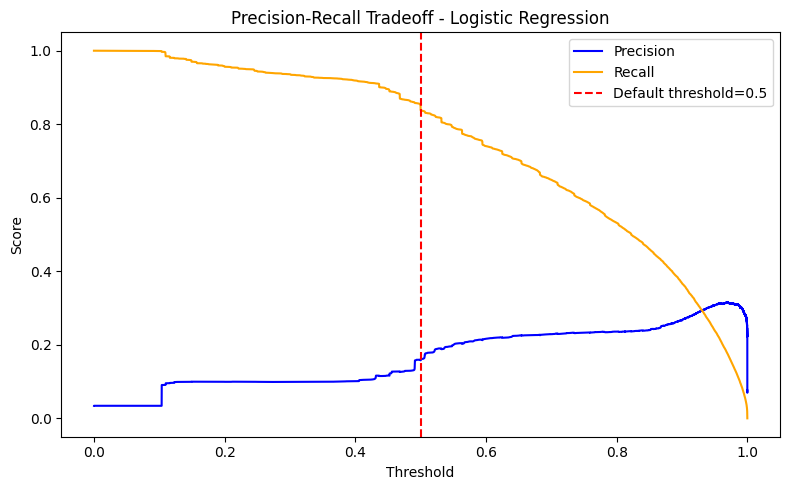

Best threshold for F1: 0.654
At this threshold - Precision: 0.226, Recall: 0.699, F1: 0.342


In [13]:
# Find optimal threshold for Logistic Regression
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Plot precision-recall tradeoff
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='orange')
plt.axvline(x=0.5, color='red', linestyle='--', label='Default threshold=0.5')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('pr_tradeoff.png', dpi=150)
plt.show()

# Find threshold where F1 is maximised
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best threshold for F1: {best_threshold:.3f}")
print(f"At this threshold - Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

In [14]:
# Apply optimised threshold
y_pred_optimised = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimised))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95   1095081
           1       0.23      0.70      0.34     38904

    accuracy                           0.91   1133985
   macro avg       0.61      0.81      0.65   1133985
weighted avg       0.96      0.91      0.93   1133985



**model 2：random forest**

In [ ]:
# Train Random Forest model and compare with Logistic Regression
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=46,
    n_jobs=-1  # 用所有CPU核心，加快速度
)
model_rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Evaluate Random Forest model performance
y_pred_rf = model_rf.predict(X_test_scaled)
y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.98      0.98   1095081
           1       0.48      0.45      0.47     38904

    accuracy                           0.96   1133985
   macro avg       0.73      0.72      0.72   1133985
weighted avg       0.96      0.96      0.96   1133985

ROC-AUC Score: 0.9029


In [ ]:
# Feature importance from Random Forest
feat_importance = pd.Series(model_rf.feature_importances_, index=features).sort_values(ascending=False)
print(feat_importance)

session_duration_min    0.320208
unique_products         0.207168
num_cart                0.148772
view_depth              0.093160
num_remove              0.074422
num_views               0.065691
single_view             0.045562
hesitation_rate         0.045016
dtype: float64


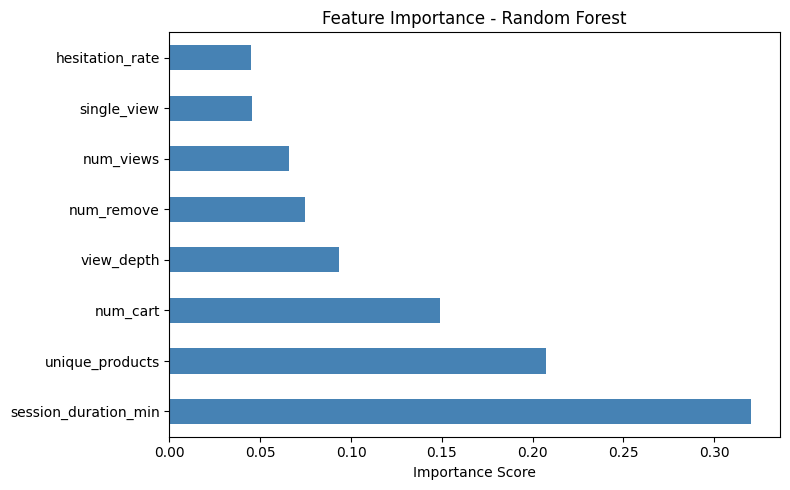

In [ ]:
# Plot feature importance
import matplotlib.pyplot as plt
feat_importance.plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

For the purpose of a recommendation system where capturing high-intent users is prioritised over precision, **Logistic Regression** was selected as the primary model.

LightGBM

In [18]:
!python -m pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 28.4 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# Train LightGBM model
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    class_weight='balanced',
    n_estimators=500,
    learning_rate=0.05,
    random_state=46,
    n_jobs=-1
)
model_lgb.fit(X_train_scaled, y_train)

[LightGBM] [Info] Number of positive: 116713, number of negative: 3285242
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.362260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1150
[LightGBM] [Info] Number of data points in the train set: 3401955, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
# Evaluate LightGBM model
y_pred_lgb = model_lgb.predict(X_test_scaled)
y_prob_lgb = model_lgb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lgb):.4f}")

c:\Users\sungu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sungu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.89      0.94   1095081
           1       0.23      0.98      0.38     38904

    accuracy                           0.89   1133985
   macro avg       0.62      0.93      0.66   1133985
weighted avg       0.97      0.89      0.92   1133985

ROC-AUC Score: 0.9764


In [21]:
# Fix feature names warning
import pandas as pd
X_test_df = pd.DataFrame(X_test_scaled, columns=features)
y_pred_lgb = model_lgb.predict(X_test_df)
y_prob_lgb = model_lgb.predict_proba(X_test_df)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")

ROC-AUC: 0.9764


In [ ]:
# Try different thresholds
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_prob_lgb >= threshold).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold={threshold}: Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

Threshold=0.3: Precision=0.208, Recall=0.992, F1=0.344
Threshold=0.4: Precision=0.219, Recall=0.987, F1=0.358
Threshold=0.5: Precision=0.233, Recall=0.977, F1=0.377
Threshold=0.6: Precision=0.253, Recall=0.960, F1=0.400


In [26]:
# Apply threshold 0.3 and evaluate final LightGBM model
y_pred_final = (y_prob_lgb >= 0.3).astype(int)

print("Final LightGBM Model (threshold=0.3)")
print("="*50)
print(classification_report(y_test, y_pred_final))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(f"\nPredicted buyers: {y_pred_final.sum():,}")
print(f"Actual buyers:    {y_test.sum():,}")

Final LightGBM Model (threshold=0.3)
              precision    recall  f1-score   support

           0       1.00      0.87      0.93   1095081
           1       0.21      0.99      0.34     38904

    accuracy                           0.87   1133985
   macro avg       0.60      0.93      0.64   1133985
weighted avg       0.97      0.87      0.91   1133985

ROC-AUC: 0.9764

Predicted buyers: 185,658
Actual buyers:    38,904


Segmentation


In [31]:
# Run segmentation using LightGBM probabilities
all_sessions_scaled = pd.DataFrame(scaler.transform(model_df[features]), columns=features)
model_df['purchase_prob'] = model_lgb.predict_proba(all_sessions_scaled)[:, 1]

# Assign segments based on probability distribution
def assign_segment(prob):
    if prob >= 0.733:        #90th percentile
        return 'High Intent'
    elif prob >= 0.023:      #75th percentile
        return 'Medium Intent'
    else:
        return 'Low Intent'

model_df['segment'] = model_df['purchase_prob'].apply(assign_segment)

print(model_df['segment'].value_counts())
print()
print(model_df.groupby('segment')['converted'].mean())

segment
Low Intent       3400295
Medium Intent     682463
High Intent       453182
Name: count, dtype: int64

segment
High Intent      0.311182
Low Intent       0.000017
Medium Intent    0.021301
Name: converted, dtype: float64


In [29]:
# Check LightGBM probability distribution
print(model_df['purchase_prob'].describe())
print()
print(model_df['purchase_prob'].quantile([0.25, 0.5, 0.75, 0.9, 0.95]))

count    4.535940e+06
mean     1.316803e-01
std      2.870692e-01
min      5.883148e-06
25%      3.327772e-05
50%      3.327772e-05
75%      2.340405e-02
max      1.000000e+00
Name: purchase_prob, dtype: float64

0.25    0.000033
0.50    0.000033
0.75    0.023404
0.90    0.732701
0.95    0.888217
Name: purchase_prob, dtype: float64


In [32]:
# Save updated segmentation
model_df.to_csv('sessions_modeled_lgb.csv', index=False)
print(f"Saved: sessions_modeled_lgb.csv")
print(f"High Intent non-converting: {len(model_df[(model_df['segment']=='High Intent') & (model_df['converted']==0)]):,}")

Saved: sessions_modeled_lgb.csv
High Intent non-converting: 312,160
